# 📊 InsuraSight — Notebook 01 : Exploratory Data Analysis

Analyse exploratoire complète du portefeuille assurance IARD.

**Plan :**
1. Chargement des données
2. Profil du portefeuille (clients, polices)
3. Analyse des sinistres (fréquence, sévérité, types)
4. KPIs sinistralité (S/P, Loss Ratio, fréquence)
5. Corrélations et axes de risque
6. Tendances temporelles

> **Pré-requis** : exécuter d'abord `src/ingestion/generate_data.py` pour générer les données dans `data/raw/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
os.makedirs("reports/figures", exist_ok=True)

# Palette InsuraSight
COLORS = {
    "primary"   : "#1B4F72",
    "secondary" : "#2E86C1",
    "accent"    : "#E74C3C",
    "success"   : "#27AE60",
    "warn"      : "#F39C12",
    "neutral"   : "#5D6D7E",
    "light"     : "#D6EAF8",
}
PALETTE3 = [COLORS["primary"], COLORS["secondary"], COLORS["accent"]]

plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
})

print("✅ Imports OK")

✅ Imports OK


## 1. Chargement des données

On charge les 4 tables CSV générées par `generate_data.py`.

In [2]:
df_clients   = pd.read_csv("data/raw/clients.csv")
df_polices   = pd.read_csv("data/raw/polices.csv")
df_sinistres = pd.read_csv("data/raw/sinistres.csv",
                            parse_dates=["date_survenance", "date_declaration"])
df_expo      = pd.read_csv("data/raw/exposition_mensuelle.csv")

df_expo["mois_dt"]      = pd.to_datetime(df_expo["mois"])
df_sinistres["annee"]   = df_sinistres["date_survenance"].dt.year
df_sinistres["mois_dt"] = df_sinistres["date_survenance"].dt.to_period("M").dt.to_timestamp()

print(f"Clients   : {len(df_clients):,}")
print(f"Polices   : {len(df_polices):,}")
print(f"Sinistres : {len(df_sinistres):,}")
print(f"Exposition: {len(df_expo):,} lignes mensuelles")
df_sinistres.head(3)

Clients   : 5,000
Polices   : 7,200
Sinistres : 3,123
Exposition: 189,898 lignes mensuelles


,sinistre_id,police_id,client_id,type_produit,type_sinistre,date_survenance,date_declaration,montant_reclame,montant_indemnise,statut,nb_jours_traitement,delai_declaration_j,fraude_potentielle,annee,mois_dt
0,SIN0000001,POL000005,CLT03993,Habitation,Dégât des eaux,2022-06-26,2022-07-03,2135,1889,Litigieux,77,7,0,2022,2022-06-01
1,SIN0000002,POL000007,CLT00209,Santé,Maternité,2023-01-16,2023-01-28,1848,1406,Fermé,29,12,0,2023,2023-01-01
2,SIN0000003,POL000007,CLT00209,Santé,Soins courants,2024-07-16,2024-07-28,170,117,Fermé,22,12,0,2024,2024-07-01


## 2. Profil du portefeuille

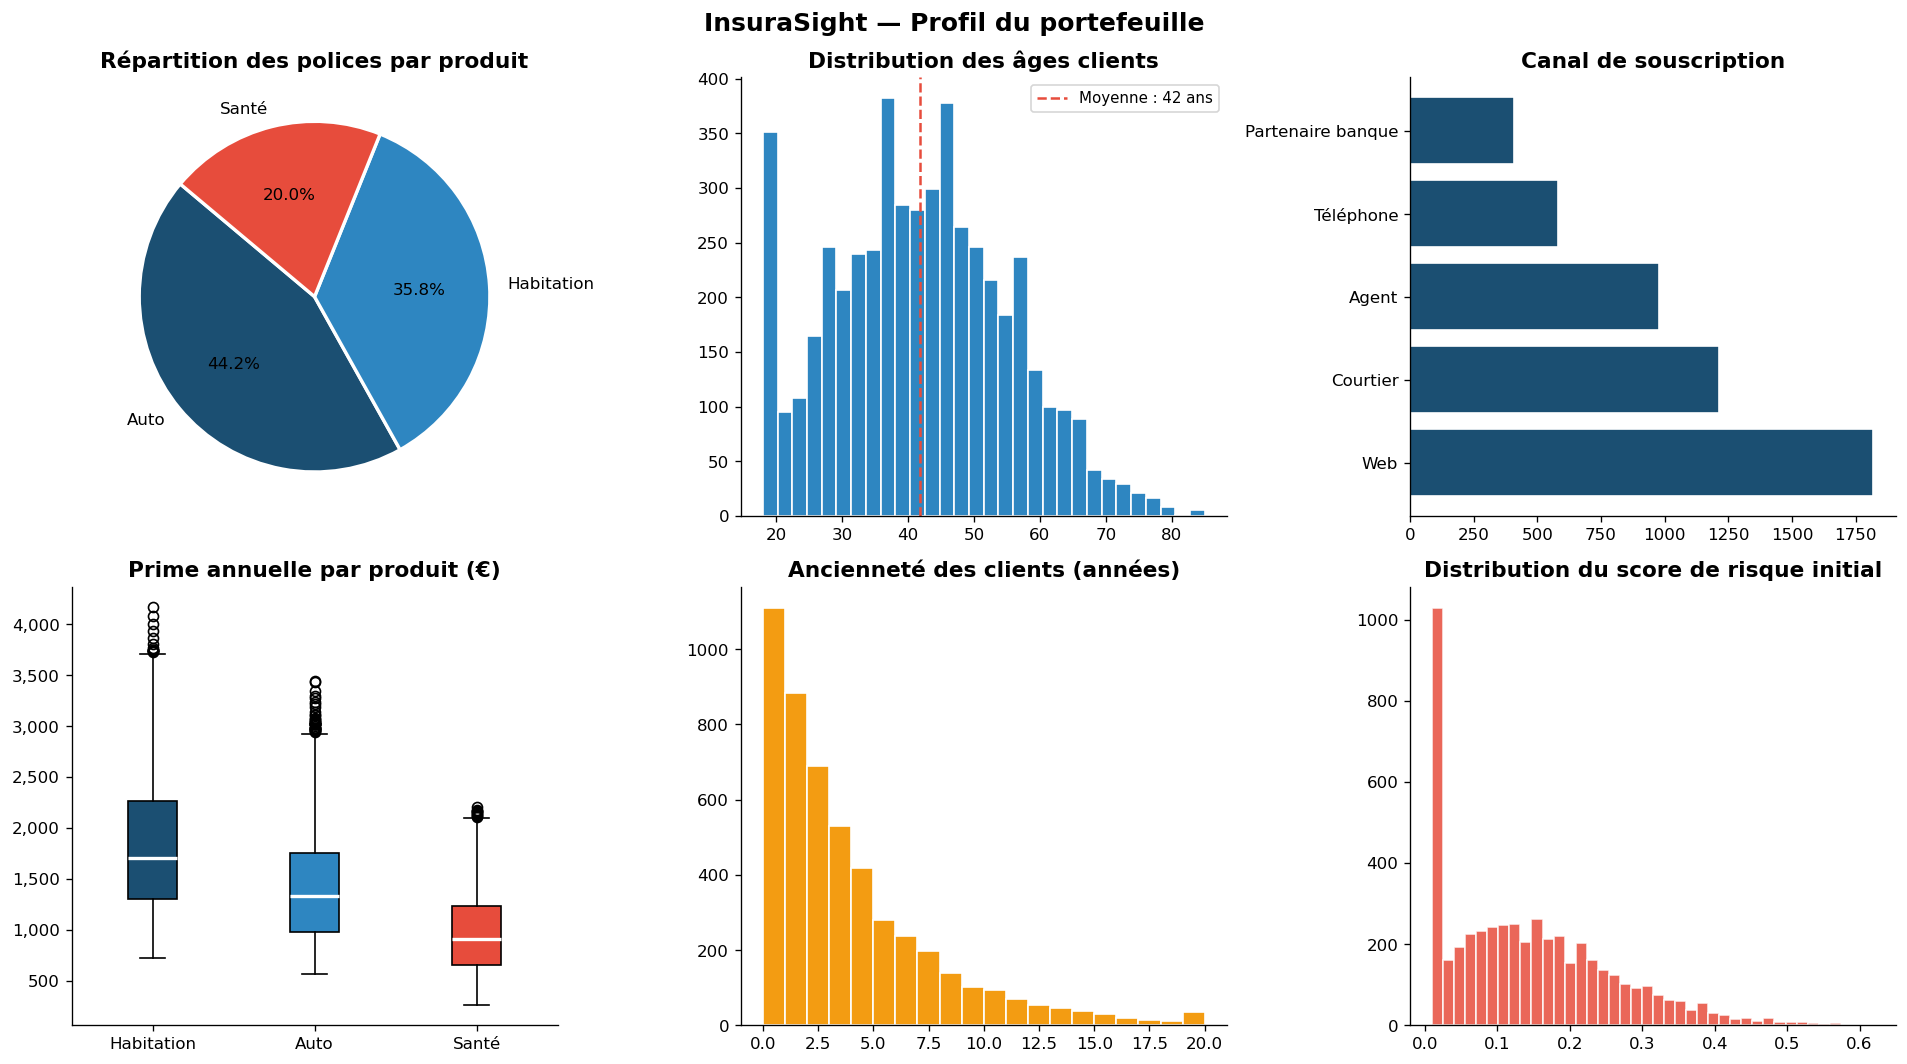

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("InsuraSight — Profil du portefeuille", fontsize=15, fontweight="bold")

# Répartition produits
vc = df_polices["type_produit"].value_counts()
axes[0,0].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
              colors=PALETTE3, startangle=140,
              wedgeprops={"edgecolor":"white","linewidth":2})
axes[0,0].set_title("Répartition des polices par produit")

# Distribution âges
axes[0,1].hist(df_clients["age"], bins=30, color=COLORS["secondary"], edgecolor="white")
axes[0,1].axvline(df_clients["age"].mean(), color=COLORS["accent"], linestyle="--",
                   label=f'Moyenne : {df_clients["age"].mean():.0f} ans')
axes[0,1].set_title("Distribution des âges clients")
axes[0,1].legend(fontsize=9)

# Canal de souscription
canal = df_clients["canal_souscription"].value_counts()
axes[0,2].barh(canal.index, canal.values, color=COLORS["primary"], edgecolor="white")
axes[0,2].set_title("Canal de souscription")

# Prime annuelle par produit
produits = df_polices["type_produit"].unique()
data_bp = [df_polices[df_polices["type_produit"]==p]["prime_annuelle"].values for p in produits]
bp = axes[1,0].boxplot(data_bp, patch_artist=True, labels=produits,
                        medianprops={"color":"white","linewidth":2})
for patch, color in zip(bp["boxes"], PALETTE3):
    patch.set_facecolor(color)
axes[1,0].set_title("Prime annuelle par produit (€)")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# Ancienneté
axes[1,1].hist(df_clients["anciennete_annees"], bins=20, color=COLORS["warn"], edgecolor="white")
axes[1,1].set_title("Ancienneté des clients (années)")

# Score de risque
axes[1,2].hist(df_clients["score_risque_init"], bins=40, color=COLORS["accent"],
               edgecolor="white", alpha=0.85)
axes[1,2].set_title("Distribution du score de risque initial")

plt.tight_layout()
plt.savefig("reports/figures/01_profil_portefeuille.png", bbox_inches="tight")
plt.show()

## 3. Analyse des sinistres

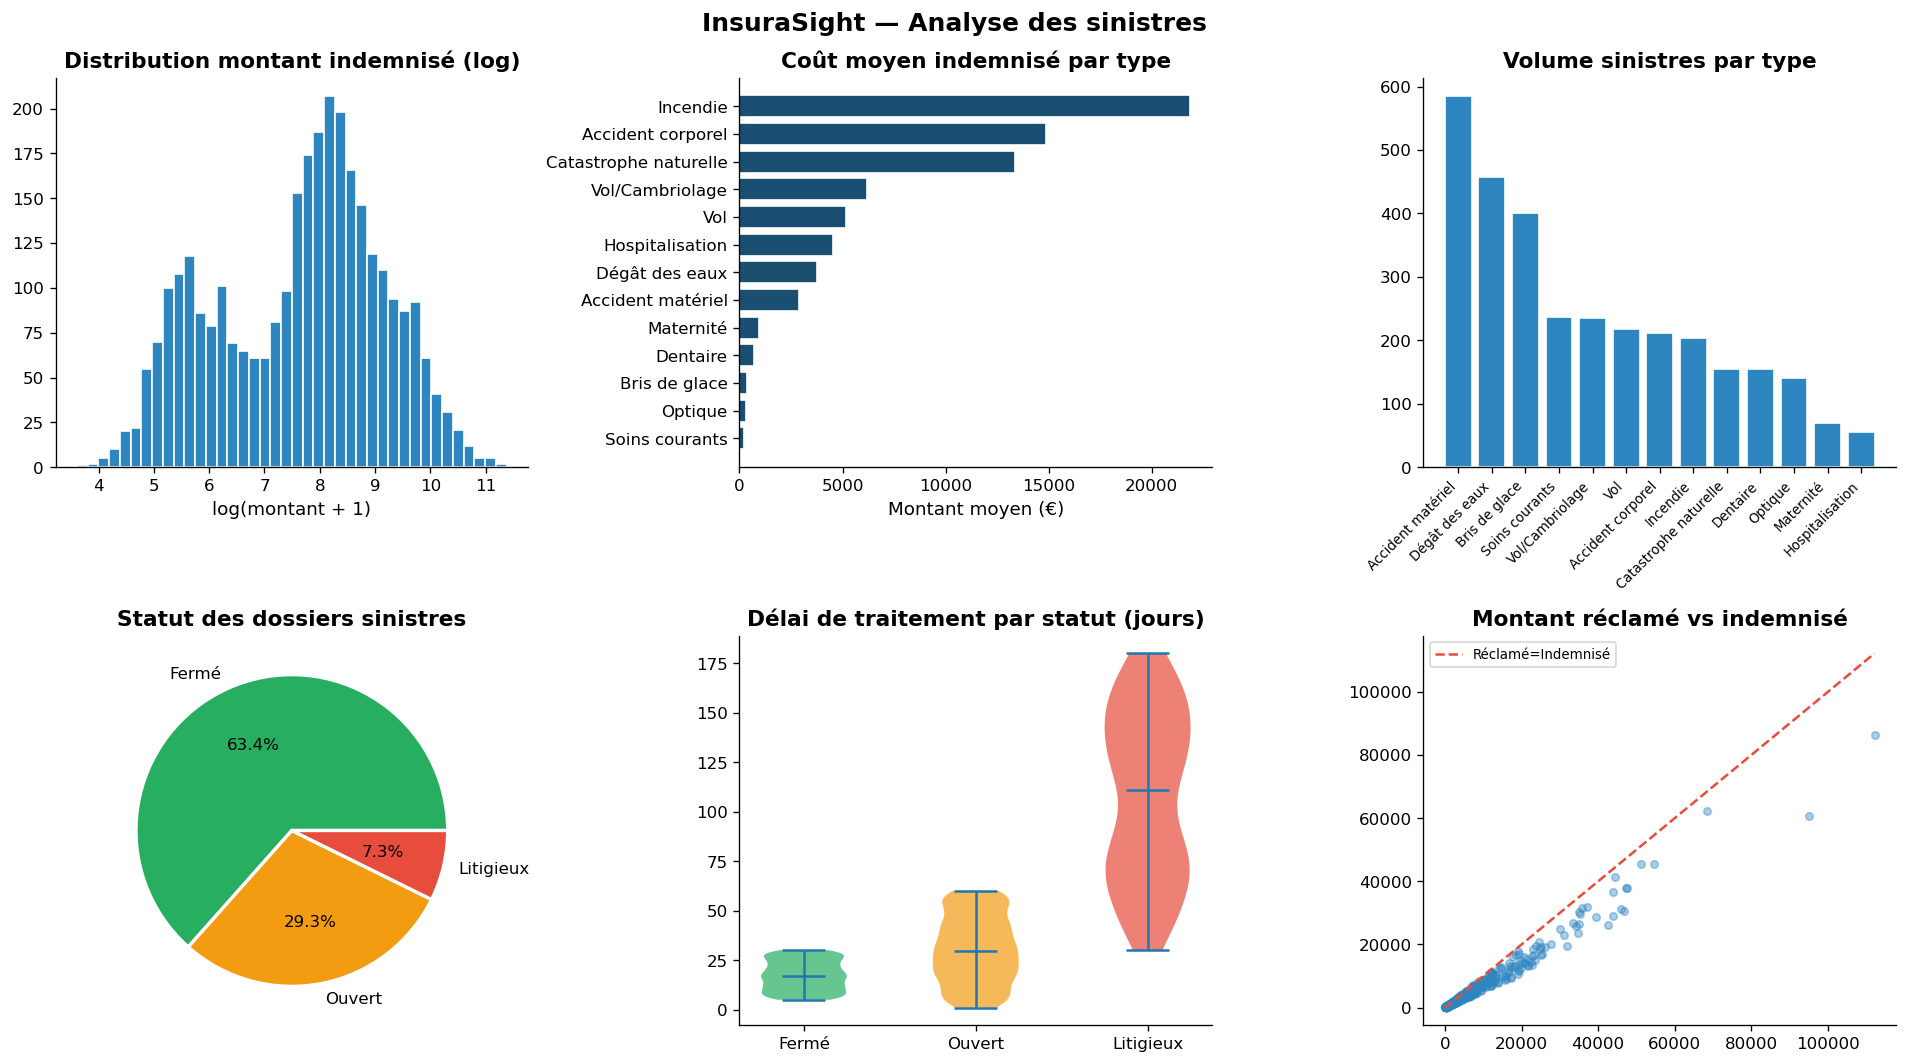

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("InsuraSight — Analyse des sinistres", fontsize=15, fontweight="bold")

# Distribution montant (log)
log_vals = np.log1p(df_sinistres["montant_indemnise"])
axes[0,0].hist(log_vals, bins=40, color=COLORS["secondary"], edgecolor="white")
axes[0,0].set_title("Distribution montant indemnisé (log)")
axes[0,0].set_xlabel("log(montant + 1)")

# Coût moyen par type
cout_type = df_sinistres.groupby("type_sinistre")["montant_indemnise"].mean().sort_values()
axes[0,1].barh(cout_type.index, cout_type.values, color=COLORS["primary"], edgecolor="white")
axes[0,1].set_title("Coût moyen indemnisé par type")
axes[0,1].set_xlabel("Montant moyen (€)")

# Volume par type
nb_type = df_sinistres["type_sinistre"].value_counts()
axes[0,2].bar(range(len(nb_type)), nb_type.values, color=COLORS["secondary"], edgecolor="white")
axes[0,2].set_xticks(range(len(nb_type)))
axes[0,2].set_xticklabels(nb_type.index, rotation=45, ha="right", fontsize=8)
axes[0,2].set_title("Volume sinistres par type")

# Statuts
statut = df_sinistres["statut"].value_counts()
axes[1,0].pie(statut.values, labels=statut.index, autopct="%1.1f%%",
              colors=[COLORS["success"], COLORS["warn"], COLORS["accent"]][:len(statut)],
              wedgeprops={"edgecolor":"white","linewidth":2})
axes[1,0].set_title("Statut des dossiers sinistres")

# Délai traitement par statut
statuts_order = [s for s in ["Fermé","Ouvert","Litigieux"] if s in df_sinistres["statut"].values]
data_v = [df_sinistres[df_sinistres["statut"]==s]["nb_jours_traitement"].values for s in statuts_order]
vp = axes[1,1].violinplot(data_v, positions=range(len(statuts_order)), showmedians=True)
for body, color in zip(vp["bodies"], [COLORS["success"], COLORS["warn"], COLORS["accent"]]):
    body.set_facecolor(color); body.set_alpha(0.7)
axes[1,1].set_xticks(range(len(statuts_order)))
axes[1,1].set_xticklabels(statuts_order)
axes[1,1].set_title("Délai de traitement par statut (jours)")

# Réclamé vs indemnisé
sample = df_sinistres.sample(min(500, len(df_sinistres)), random_state=42)
axes[1,2].scatter(sample["montant_reclame"], sample["montant_indemnise"],
                  alpha=0.4, color=COLORS["secondary"], s=20)
max_val = max(sample["montant_reclame"].max(), sample["montant_indemnise"].max())
axes[1,2].plot([0,max_val],[0,max_val],"--", color=COLORS["accent"], label="Réclamé=Indemnisé")
axes[1,2].set_title("Montant réclamé vs indemnisé")
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("reports/figures/02_analyse_sinistres.png", bbox_inches="tight")
plt.show()

## 4. KPIs Sinistralité (S/P, Loss Ratio, fréquence)

In [5]:
# Calcul des KPIs annuels
df_2023 = df_sinistres[df_sinistres["annee"] == 2023]
exp_2023 = df_expo[df_expo["mois_dt"].dt.year == 2023]

primes      = exp_2023["prime_acquise"].sum()
sin_pays    = df_2023["montant_indemnise"].sum()
loss_ratio  = sin_pays / primes
freq        = len(df_2023) / len(df_polices[df_polices["statut"] == "Active"])
cout_moyen  = df_2023["montant_indemnise"].mean()
delai_moyen = df_2023["nb_jours_traitement"].mean()

print(f"{'KPI':<30} {'Valeur':>15}")
print("-" * 47)
print(f"{'Primes acquises (2023)':<30} {primes:>14,.0f} €")
print(f"{'Sinistres payés (2023)':<30} {sin_pays:>14,.0f} €")
print(f"{'Loss Ratio (S/P)':<30} {loss_ratio:>14.2%}")
print(f"{'Fréquence sinistre':<30} {freq:>14.4f}")
print(f"{'Coût moyen indemnisé':<30} {cout_moyen:>14,.0f} €")
print(f"{'Délai moyen traitement':<30} {delai_moyen:>14.1f} j")

KPI                                     Valeur
-----------------------------------------------
Primes acquises (2023)              7,681,151 €
Sinistres payés (2023)              4,995,659 €
Loss Ratio (S/P)                       65.04%
Fréquence sinistre                     0.1686
Coût moyen indemnisé                    5,119 €
Délai moyen traitement                   27.9 j


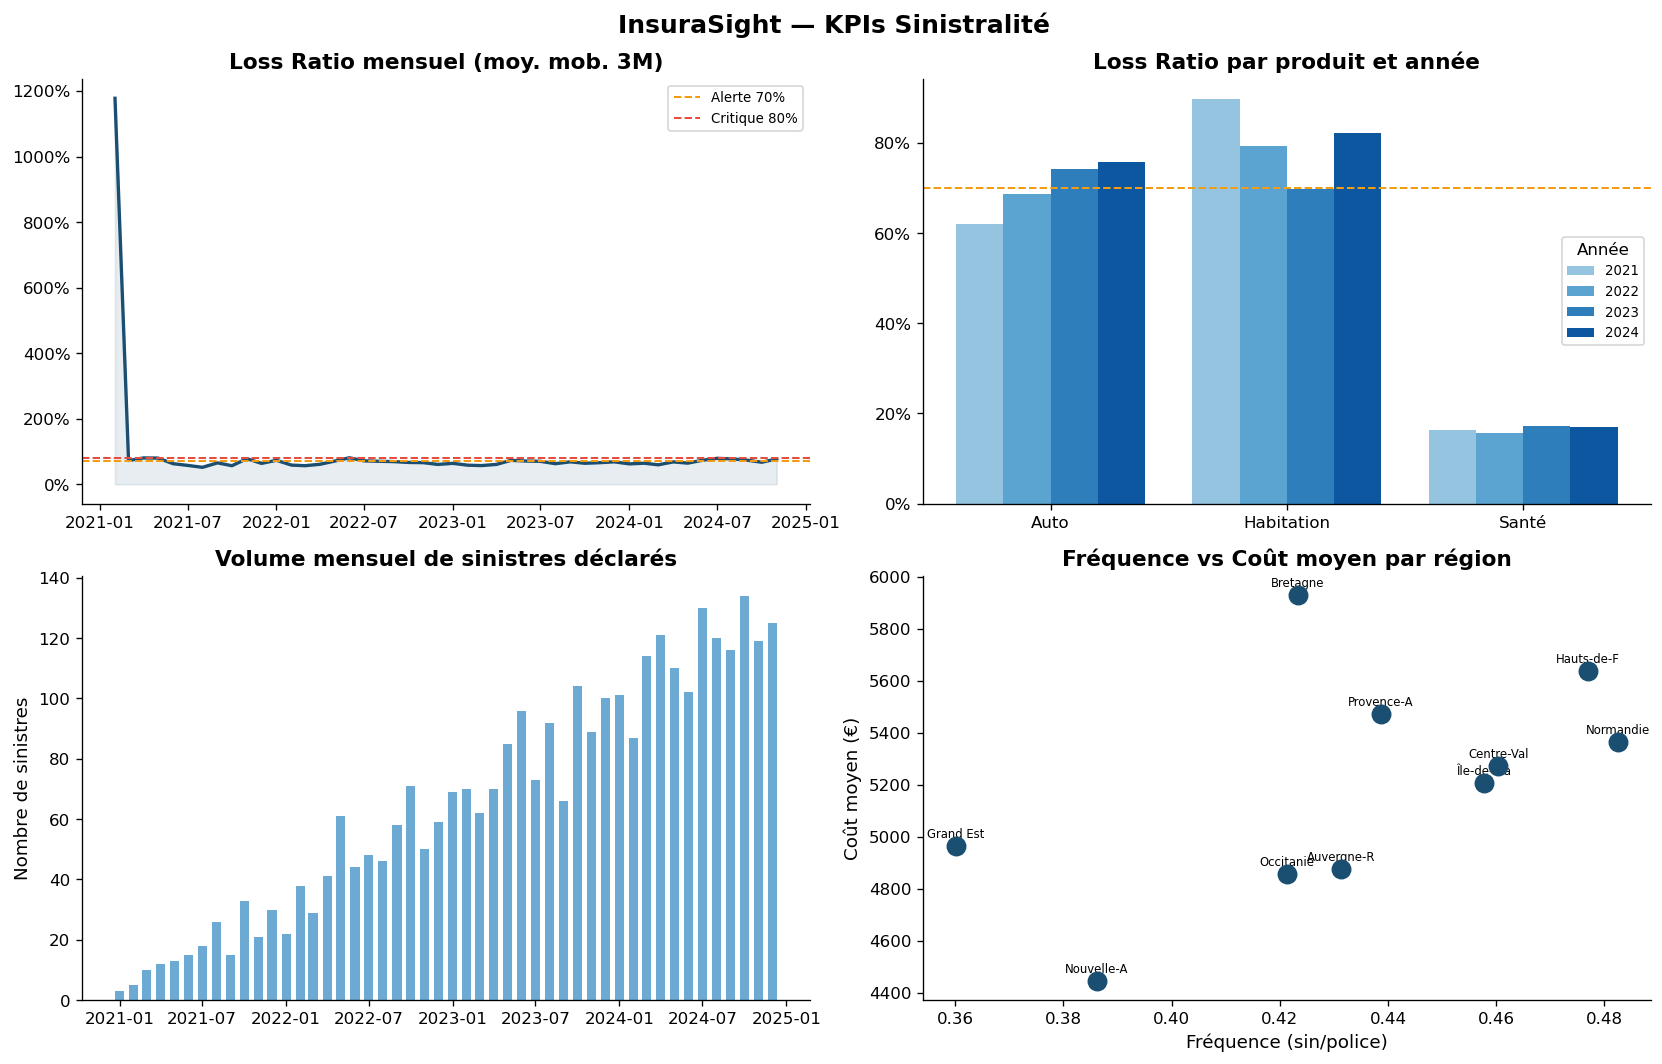

In [6]:
# Graphiques KPIs
sin_m = df_sinistres.groupby("mois_dt")["montant_indemnise"].sum().reset_index()
exp_m = df_expo.groupby("mois_dt")["prime_acquise"].sum().reset_index()
kpi_m = sin_m.merge(exp_m, on="mois_dt").sort_values("mois_dt")
kpi_m["loss_ratio"] = kpi_m["montant_indemnise"] / kpi_m["prime_acquise"].clip(lower=1)
kpi_m["lr_roll"]    = kpi_m["loss_ratio"].rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("InsuraSight — KPIs Sinistralité", fontsize=15, fontweight="bold")

# Loss Ratio mensuel
axes[0,0].plot(kpi_m["mois_dt"], kpi_m["lr_roll"], color=COLORS["primary"], linewidth=2)
axes[0,0].fill_between(kpi_m["mois_dt"], kpi_m["lr_roll"], alpha=0.1, color=COLORS["primary"])
axes[0,0].axhline(0.70, color=COLORS["warn"],  linestyle="--", linewidth=1.2, label="Alerte 70%")
axes[0,0].axhline(0.80, color=COLORS["accent"],linestyle="--", linewidth=1.2, label="Critique 80%")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0,0].set_title("Loss Ratio mensuel (moy. mob. 3M)")
axes[0,0].legend(fontsize=8)

# S/P par produit et année
sin_pa = df_sinistres.groupby(["annee","type_produit"])["montant_indemnise"].sum().reset_index()
exp_pa = (df_expo.assign(annee=df_expo["mois_dt"].dt.year)
          .groupby(["annee","type_produit"])["prime_acquise"].sum().reset_index())
kpi_pa = sin_pa.merge(exp_pa, on=["annee","type_produit"])
kpi_pa["lr"] = kpi_pa["montant_indemnise"] / kpi_pa["prime_acquise"]
annees = sorted(kpi_pa["annee"].unique())
produits_list = ["Auto","Habitation","Santé"]
x = np.arange(len(produits_list)); w = 0.2
for i, an in enumerate(annees):
    vals = [kpi_pa[(kpi_pa["annee"]==an)&(kpi_pa["type_produit"]==p)]["lr"].values for p in produits_list]
    vals = [v[0] if len(v)>0 else 0 for v in vals]
    axes[0,1].bar(x + i*w, vals, w, label=str(an), color=plt.cm.Blues(0.4+i*0.15))
axes[0,1].axhline(0.70, color=COLORS["warn"], linestyle="--", linewidth=1.2)
axes[0,1].set_xticks(x + w*(len(annees)-1)/2); axes[0,1].set_xticklabels(produits_list)
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0,1].set_title("Loss Ratio par produit et année")
axes[0,1].legend(fontsize=8, title="Année")

# Volume mensuel sinistres
nb_sin_m = df_sinistres.groupby("mois_dt").size().reset_index(name="nb")
axes[1,0].bar(nb_sin_m["mois_dt"], nb_sin_m["nb"], width=20,
              color=COLORS["secondary"], edgecolor="none", alpha=0.7)
axes[1,0].set_title("Volume mensuel de sinistres déclarés")
axes[1,0].set_ylabel("Nombre de sinistres")

# Fréquence vs coût par région
sin_reg = df_sinistres.merge(df_polices[["police_id","region"]], on="police_id", how="left")
reg_freq = sin_reg.groupby("region").size() / df_polices.groupby("region").size()
reg_cout = sin_reg.groupby("region")["montant_indemnise"].mean()
regs = reg_freq.index.intersection(reg_cout.index)
axes[1,1].scatter(reg_freq[regs], reg_cout[regs], s=120, color=COLORS["primary"], zorder=5)
for r in regs:
    axes[1,1].annotate(r[:10], (reg_freq[r], reg_cout[r]), fontsize=7,
                       xytext=(0,5), textcoords="offset points", ha="center")
axes[1,1].set_title("Fréquence vs Coût moyen par région")
axes[1,1].set_xlabel("Fréquence (sin/police)"); axes[1,1].set_ylabel("Coût moyen (€)")

plt.tight_layout()
plt.savefig("reports/figures/03_kpis_sinistralite.png", bbox_inches="tight")
plt.show()

## 5. Corrélations et axes de risque

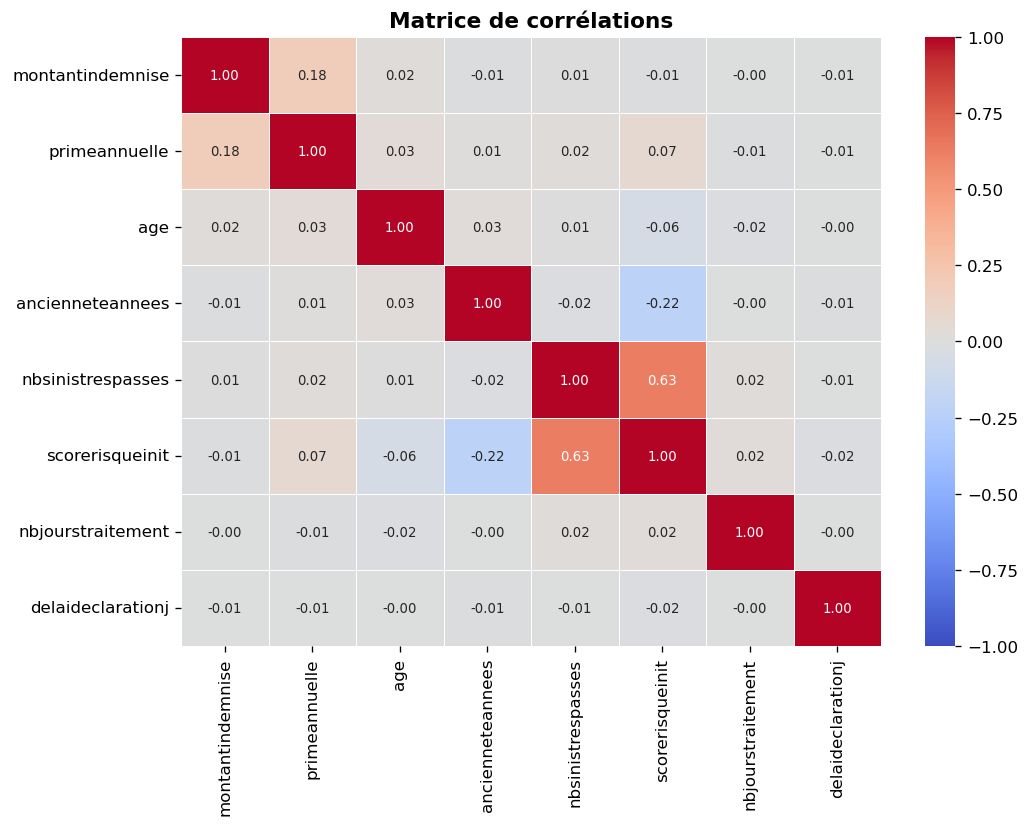

In [8]:
df_merged = (df_sinistres
             .merge(df_polices[["police_id","prime_annuelle","niveau_garantie"]], on="police_id")
             .merge(df_clients[["client_id","age","anciennete_annees",
                                "nb_sinistres_passes","score_risque_init"]], on="client_id"))

num_cols = ["montant_indemnise","prime_annuelle","age","anciennete_annees",
            "nb_sinistres_passes","score_risque_init","nb_jours_traitement","delai_declaration_j"]
corr = df_merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size": 8},
            xticklabels=[c.replace("_","") for c in num_cols],
            yticklabels=[c.replace("_","") for c in num_cols])
ax.set_title("Matrice de corrélations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/04_correlations.png", bbox_inches="tight")
plt.show()

## 6. Tendances temporelles

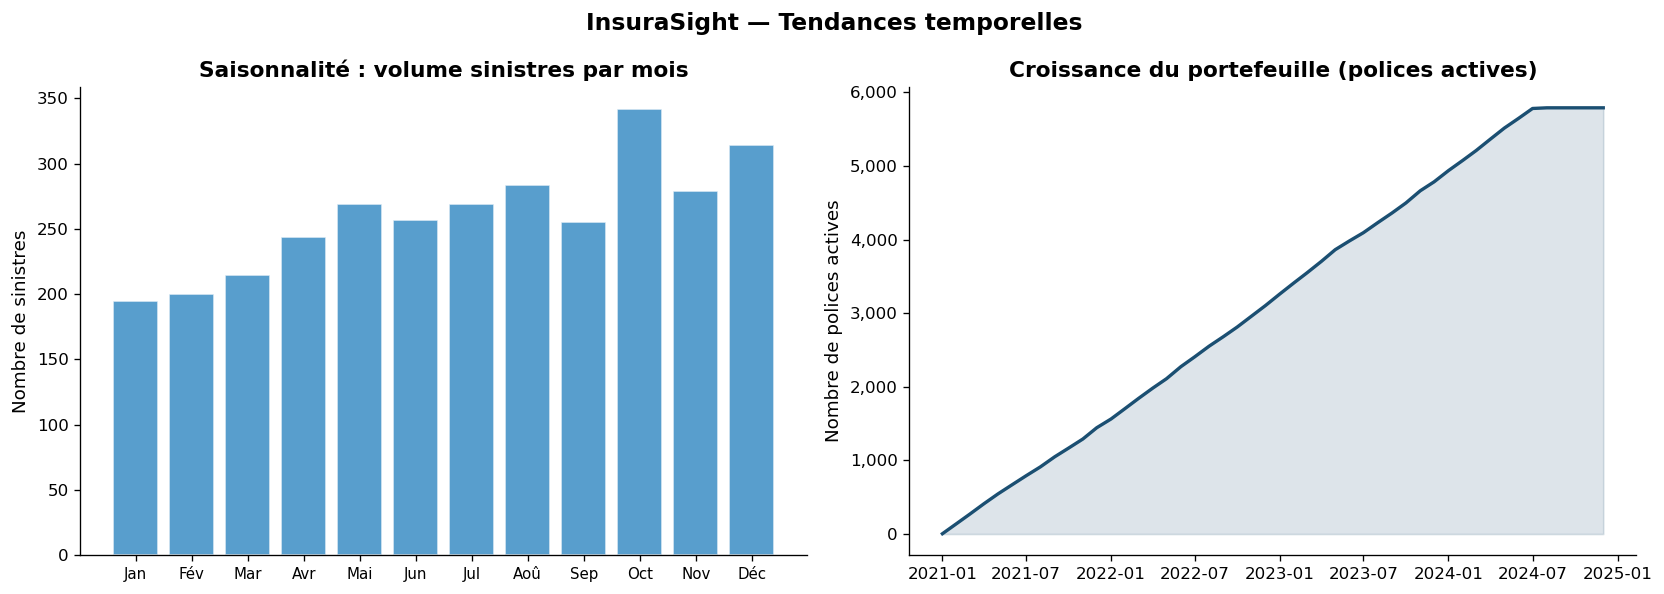


✅ EDA terminée — figures sauvegardées dans reports/figures/


In [9]:
df_sinistres["mois_annee"] = df_sinistres["date_survenance"].dt.month
sin_mois = df_sinistres.groupby("mois_annee").agg(nb=("sinistre_id","count"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("InsuraSight — Tendances temporelles", fontsize=14, fontweight="bold")

# Saisonnalité
noms_mois = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
axes[0].bar(range(1,13), sin_mois["nb"], color=COLORS["secondary"], edgecolor="white", alpha=0.8)
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(noms_mois, fontsize=9)
axes[0].set_title("Saisonnalité : volume sinistres par mois")
axes[0].set_ylabel("Nombre de sinistres")

# Croissance portefeuille
pol_actives = (df_expo[df_expo["statut_police"]=="Active"]
               .groupby("mois_dt")["police_id"].nunique())
axes[1].plot(pol_actives.index, pol_actives.values, color=COLORS["primary"], linewidth=2)
axes[1].fill_between(pol_actives.index, pol_actives.values, alpha=0.15, color=COLORS["primary"])
axes[1].set_title("Croissance du portefeuille (polices actives)")
axes[1].set_ylabel("Nombre de polices actives")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("reports/figures/05_tendances_temporelles.png", bbox_inches="tight")
plt.show()

print("\n✅ EDA terminée — figures sauvegardées dans reports/figures/")